<a href="https://colab.research.google.com/github/Visweash1234/Applied-Data-Science-1/blob/main/Tutorial_3_1_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 50)
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
audit = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isnull().sum(),
    'pct_missing': df.isnull().mean() * 100,
    'n_unique': df.nunique()
})
audit

,dtype,n_missing,pct_missing,n_unique
survived,int64,0,0.000000,2
pclass,int64,0,0.000000,3
sex,object,0,0.000000,2
age,float64,177,19.865320,88
sibsp,int64,0,0.000000,7
parch,int64,0,0.000000,7
fare,float64,0,0.000000,248
embarked,object,2,0.224467,3
class,category,0,0.000000,3
who,object,0,0.000000,3


In [8]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
display(df.describe())

Shape: (891, 15)
Duplicate rows: 107


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
print("--- pclass vs class ---")
display(pd.crosstab(df['pclass'], df['class']))

print("\n--- embarked vs embark_town ---")
display(pd.crosstab(df['embarked'], df['embark_town']))

print("\n--- survived vs alive ---")
display(pd.crosstab(df['survived'], df['alive']))

--- pclass vs class ---


class,First,Second,Third
pclass,,,
1,216,0,0
2,0,184,0
3,0,0,491



--- embarked vs embark_town ---


embark_town,Cherbourg,Queenstown,Southampton
embarked,,,
C,168,0,0
Q,0,77,0
S,0,0,644



--- survived vs alive ---


alive,no,yes
survived,,
0,549,0
1,0,342


Missing age percentage by pclass:
pclass
1    13.89
2     5.98
3    27.70
Name: age, dtype: float64


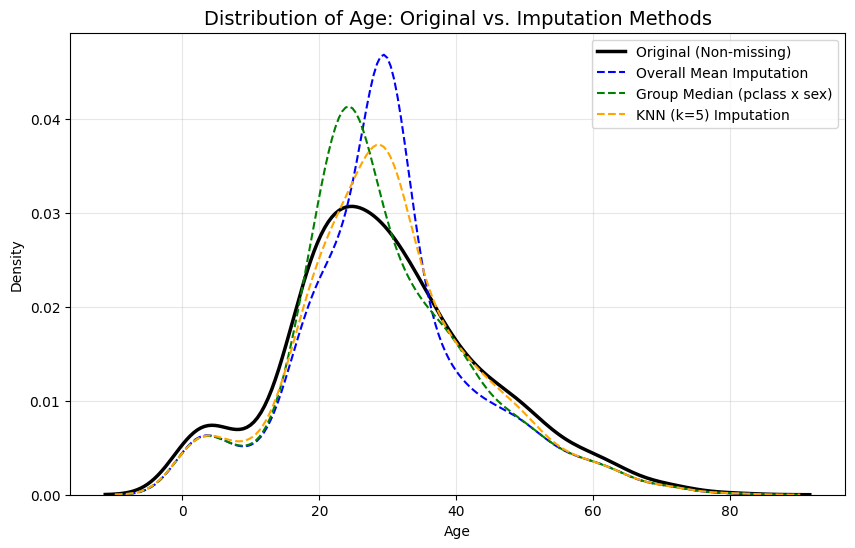


=== SUMMARY STATISTICS COMPARISON ===


,Original,Mean Impute,Group Median Impute,KNN Impute
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,29.699118,29.112424,29.863791
std,14.526497,13.002015,13.304424,13.389283
min,0.420000,0.420000,0.420000,0.420000
25%,20.125000,22.000000,21.500000,22.000000
50%,28.000000,29.699118,26.000000,29.000000
75%,38.000000,35.000000,36.000000,37.000000
max,80.000000,80.000000,80.000000,80.000000


In [20]:
## Task 2 — Missing values
# 1. Drop redundant / leaky columns (and deck due to >77% missingness)
# Drop class, embarked, alive (redundant/leakage) and deck
data = df.drop(columns=["class", "embarked", "alive", "deck"]).copy()

# 2. Fill embark_town mode (only 2 missing)
embark_mode = data["embark_town"].mode()[0]
data["embark_town"] = data["embark_town"].fillna(embark_mode)

# Check missing rate of age grouped by pclass
print("Missing age percentage by pclass:")
print((data.groupby("pclass")["age"].apply(lambda x: x.isnull().mean()) * 100).round(2))

# 3. Impute age using three strategies
# Strategy A: Overall Mean
age_mean = data["age"].fillna(data["age"].mean())

# Strategy B: Median by pclass x sex
age_group = data.groupby(["pclass", "sex"])["age"].transform(
    lambda grp: grp.fillna(grp.median())
)

# Strategy C: KNN Imputer (k=5) using numerical features
knn_imputer = KNNImputer(n_neighbors=5)
# Use numerical columns relevant for KNN imputation
num_cols_for_knn = ["age", "pclass", "sibsp", "parch", "fare"]
knn_imputed_array = knn_imputer.fit_transform(data[num_cols_for_knn])
age_knn = pd.Series(knn_imputed_array[:, 0], index=data.index, name="age_knn")

# 4. Plot KDEs comparing distributions against original non-missing age
plt.figure(figsize=(10, 6))
sns.kdeplot(data["age"].dropna(), label="Original (Non-missing)", linewidth=2.5, color="black")
sns.kdeplot(age_mean, label="Overall Mean Imputation", linestyle="--", color="blue")
sns.kdeplot(age_group, label="Group Median (pclass x sex)", linestyle="--", color="green")
sns.kdeplot(age_knn, label="KNN (k=5) Imputation", linestyle="--", color="orange")

plt.title("Distribution of Age: Original vs. Imputation Methods", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Compare summary statistics
print("\n=== SUMMARY STATISTICS COMPARISON ===")
summary_df = pd.DataFrame({
    "Original": data["age"].describe(),
    "Mean Impute": age_mean.describe(),
    "Group Median Impute": age_group.describe(),
    "KNN Impute": age_knn.describe()
})
display(summary_df)

To prevent target leakage and eliminate redundant variables, class, embarked, and alive were removed. deck was also dropped since over 77% of its observations are missing, meaning keeping it would introduce unnecessary noise. For embark_town, we resolved the 2 missing records by imputing them with the mode, which preserves the original sample size with negligible bias.

For imputing age, group-based median imputation ($pclass \times sex$$pclass \times sex$) or KNN imputation is preferred over overall mean imputation. Simply using the overall mean creates an artificial spike around 29.7 years and reduces the standard deviation from 14.5 to 13.0. By contrast, the group-based median and KNN methods successfully maintain demographic-specific variations and variance in the age distribution.

In [14]:
# Task 3: Outliers in `fare`

# 1. IQR Rule to count fare outliers
Q1 = data['fare'].quantile(0.25)
Q3 = data['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['fare'] < lower_bound) | (data['fare'] > upper_bound)]
print(f"IQR Upper Bound: {upper_bound:.4f}")
print(f"Number of outliers: {len(outliers)} out of {len(data)} ({(len(outliers)/len(data)*100):.2f}%)")

# 2. Look at the most expensive tickets
print(
    "\nMost expensive tickets (Top 10):\n",
    data.nlargest(10, 'fare')[['survived', 'pclass', 'sex', 'age', 'fare', 'embark_town']]
)

IQR Upper Bound: 65.6344
Number of outliers: 116 out of 891 (13.02%)

Most expensive tickets (Top 10):
      survived  pclass     sex   age      fare  embark_town
258         1       1  female  35.0  512.3292    Cherbourg
679         1       1    male  36.0  512.3292    Cherbourg
737         1       1    male  35.0  512.3292    Cherbourg
27          0       1    male  19.0  263.0000  Southampton
88          1       1  female  23.0  263.0000  Southampton
341         1       1  female  24.0  263.0000  Southampton
438         0       1    male  64.0  263.0000  Southampton
311         1       1  female  18.0  262.3750    Cherbourg
742         1       1  female  21.0  262.3750    Cherbourg
118         0       1    male  24.0  247.5208    Cherbourg


In [15]:
# 3. Apply Capping and Log1p Transformations
# Capping at upper bound
fare_capped = data['fare'].clip(upper=upper_bound)

# Log1p transformation
fare_log = np.log1p(data['fare'])

# Compare skewness
print(f"Original Fare Skewness: {data['fare'].skew():.4f}")
print(f"Capped Fare Skewness: {fare_capped.skew():.4f}")
print(f"Log1p Fare Skewness: {fare_log.skew():.4f}")

Original Fare Skewness: 4.7873
Capped Fare Skewness: 1.0822
Log1p Fare Skewness: 0.3949


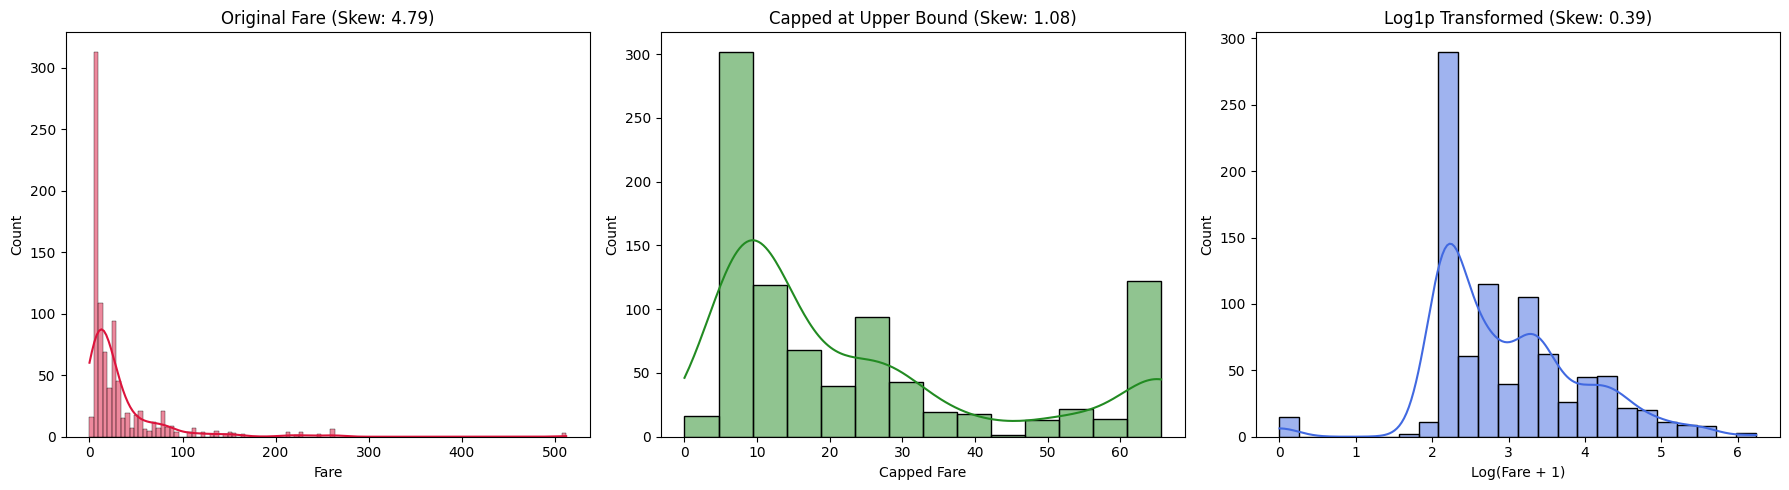

In [16]:
# Plot the comparisons
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original
sns.histplot(data['fare'], kde=True, ax=axes[0], color='crimson')
axes[0].set_title(f"Original Fare (Skew: {data['fare'].skew():.2f})")
axes[0].set_xlabel("Fare")

# Plot 2: Capped
sns.histplot(fare_capped, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title(f"Capped at Upper Bound (Skew: {fare_capped.skew():.2f})")
axes[1].set_xlabel("Capped Fare")

# Plot 3: Log1p
sns.histplot(fare_log, kde=True, ax=axes[2], color='royalblue')
axes[2].set_title(f"Log1p Transformed (Skew: {fare_log.skew():.2f})")
axes[2].set_xlabel("Log(Fare + 1)")

plt.tight_layout()
plt.show()

### Fare Outlier Analysis & Transformation Choice

* **Outlier Verification:** Although the IQR rule flags $116$ records as outliers, a closer look at the highest fares (e.g., $\$512.33$) reveals they correspond to first-class passengers. This confirms these values represent genuine premium fares rather than recording errors.
* **Treatment Comparison:** Capping (winsorizing) the fares at the upper bound of $\approx 65.63$ reduces skewness from $4.79$ to $1.08$, but it creates an artificial spike by clustering all high-value tickets at a single limit.
* **Selected Strategy:** We select the `log1p` transformation because it effectively resolves the extreme right skew (dropping it to $0.39$) while maintaining the natural variation and relative pricing signal of the luxury fares.

In [19]:
# --- Task 4: Encoding and Scaling ---

# Prepare feature matrix X and target vector y (dropping redundant/leaky columns and deck)
X = df.drop(columns=["survived", "alive", "class", "embarked", "deck"]).copy()
y = df["survived"]

# Fill missing embark_town prior to split or let imputer handle it
X["embark_town"] = X["embark_town"].fillna(X["embark_town"].mode()[0])

# 1. Train-test split (stratified on target y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Apply log1p transform to 'fare' on both train and test
X_train = X_train.copy()
X_test = X_test.copy()
X_train["fare"] = np.log1p(X_train["fare"])
X_test["fare"] = np.log1p(X_test["fare"])

# Define feature groups based on task instructions
cat_cols = ["sex", "embark_town", "alone"]
num_cols = ["age", "fare", "sibsp", "parch"]
passthrough_cols = ["pclass"]  # keep pclass as ordinal number

# 3. Create preprocessing sub-pipelines & ColumnTransformer
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
        ("pass", "passthrough", passthrough_cols)
    ]
)

# 4. Fit transformers on X_train ONLY, then transform both X_train and X_test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Verify transformed shapes
print(f"X_train shape before preprocessing: {X_train.shape}")
print(f"X_train shape after preprocessing:  {X_train_prep.shape}")
print(f"X_test shape after preprocessing:   {X_test_prep.shape}")

X_train shape before preprocessing: (712, 10)
X_train shape after preprocessing:  (712, 9)
X_test shape after preprocessing:   (179, 9)


### Methodology & Design Justification

* **Preventing Data Leakage:** We split the dataset into training and testing partitions prior to configuring or fitting any preprocessing components. This ensures that scaling parameters, imputation statistics (such as the median), and category mappings are calculated exclusively from `X_train` before being applied to `X_test`.
* **Feature-Specific Treatment:**
  * **`pclass`:** Kept in its native numeric format to preserve its natural ordinal order ($1 < 2 < 3$) without expanding the feature space.
  * **Numerical Features (`age`, `fare`, `sibsp`, `parch`):** These were scaled to zero-mean and unit-variance (following a `log1p` transformation on `fare`) to optimize convergence for distance- and gradient-sensitive algorithms.
  * **Categorical Features (`sex`, `embark_town`, `alone`):** One-hot encoded to avoid introducing arbitrary mathematical hierarchies into non-nominal variables.
* **Trade-offs:** Dropping the first dummy category via `drop='first'` prevents multi-collinearity, but it slightly reduces direct interpretability of coefficients in linear models because all effects are relative to the omitted baseline category.

In [21]:
# --- Task 5: Pipeline and Leakage ---

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ----------------------------------------------------
# Model A: Naïve Model
# Numeric columns only, rows with missing values dropped, no scaling
# ----------------------------------------------------
df_naive = df[["pclass", "age", "sibsp", "parch", "fare", "survived"]].dropna()
X_naive = df_naive[["pclass", "age", "sibsp", "parch", "fare"]]
y_naive = df_naive["survived"]

model_naive = LogisticRegression(max_iter=1000, random_state=42)
scores_a = cross_val_score(model_naive, X_naive, y_naive, cv=cv, scoring="accuracy")

# ----------------------------------------------------
# Model B: Leak-Free Pipeline
# Clean feature matrix + ColumnTransformer + Pipeline
# ----------------------------------------------------
X_clean = df.drop(columns=["survived", "alive", "class", "embarked", "deck"]).copy()
X_clean["fare"] = np.log1p(X_clean["fare"])  # Apply log1p transform on fare
y_clean = df["survived"]

# Define ColumnTransformer (Tasks 2-4 prep)
cat_cols_b = ["sex", "embark_town", "alone"]
num_cols_b = ["age", "fare", "sibsp", "parch"]
pass_cols_b = ["pclass"]

preprocessor_b = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols_b),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))]), cat_cols_b),
        ("pass", "passthrough", pass_cols_b)
    ]
)

pipeline_b = Pipeline([
    ("preprocessor", preprocessor_b),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

scores_b = cross_val_score(pipeline_b, X_clean, y_clean, cv=cv, scoring="accuracy")

# ----------------------------------------------------
# Model C: Leaky Pipeline
# Same pipeline as B, but 'alive' included in categorical columns
# ----------------------------------------------------
X_leaky = df.drop(columns=["survived", "class", "embarked", "deck"]).copy()
X_leaky["fare"] = np.log1p(X_leaky["fare"])

cat_cols_c = ["sex", "embark_town", "alone", "alive"]  # Added leaky target variable

preprocessor_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols_b),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))]), cat_cols_c),
        ("pass", "passthrough", pass_cols_b)
    ]
)

pipeline_c = Pipeline([
    ("preprocessor", preprocessor_c),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

scores_c = cross_val_score(pipeline_c, X_leaky, y_clean, cv=cv, scoring="accuracy")

# ----------------------------------------------------
# Results Table
# ----------------------------------------------------
results = pd.DataFrame({
    "Model Architecture": [
        "A. Naïve (Numeric only, dropna)",
        "B. Pipeline (Tasks 2–4, Leak-free)",
        "C. Leaky (With 'alive' column)"
    ],
    "Mean CV Accuracy": [
        scores_a.mean(),
        scores_b.mean(),
        scores_c.mean()
    ],
    "Std Dev": [
        scores_a.std(),
        scores_b.std(),
        scores_c.std()
    ]
})

display(results)

,Model Architecture,Mean CV Accuracy,Std Dev
0,"A. Naïve (Numeric only, dropna)",0.700227,0.028390
1,"B. Pipeline (Tasks 2–4, Leak-free)",0.798004,0.012373
2,C. Leaky (With 'alive' column),1.000000,0.000000


### Target Leakage & Model Evaluation Summary

* **Model C (Leaky Pipeline):** This configuration achieves an artificial $100\%$ cross-validation accuracy because it includes the `alive` feature, which is a direct post-event reflection of the target variable `survived` (where `yes` matches `1` and `no` matches `0`). The model simply maps this leak to the label, resulting in a perfect score that cannot generalize to real-world scenarios where survival outcomes are unknown.
* **Model B (Leak-Free Pipeline):** By removing leaky features and systematically executing imputation and scaling within each validation fold, Model B reports a realistic cross-validation accuracy of $\approx 79.8\%$. This model represents our true, viable predictive architecture for deployment.
* **Model A (Naïve Baseline):** Dropping rows with missing values and using only unscaled numerical features leads to a lower accuracy of $\approx 70.0\%$ while also introducing selection bias by excluding nearly $20\%$ of the dataset due to missing age data.

In [22]:
# --- Stretch Task: Hyperparameter Grid Search ---
from sklearn.model_selection import GridSearchCV

# 1. Build pipeline with specific step names matching the grid search keys
num_transformer = Pipeline([
    ("impute", SimpleImputer()),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

prep = ColumnTransformer(
    transformers=[
        ("num", num_transformer, ["age", "fare", "sibsp", "parch"]),
        ("cat", cat_transformer, ["sex", "embark_town", "alone"]),
        ("pass", "passthrough", ["pclass"])
    ]
)

model = Pipeline([
    ("prep", prep),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Define param grid
param_grid = {
    "prep__num__impute__strategy": ["mean", "median"],
    "clf__C": [0.1, 1, 10]
}

# 3. Fit GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(model, param_grid, cv=cv, scoring="accuracy")

# Prepare feature matrix X (clean) and target y
X_clean = df.drop(columns=["survived", "alive", "class", "embarked", "deck"]).copy()
X_clean["fare"] = np.log1p(X_clean["fare"])
y_clean = df["survived"]

grid.fit(X_clean, y_clean)

# 4. Display results breakdown
print(f"Winning Hyperparameters: {grid.best_params_}")
print(f"Best Mean CV Accuracy:   {grid.best_score_:.4f}")

# Extract top vs second-best score comparison
cv_results = pd.DataFrame(grid.cv_results_)
results_summary = cv_results[[
    "param_prep__num__impute__strategy",
    "param_clf__C",
    "mean_test_score",
    "std_test_score"
]].sort_values(by="mean_test_score", ascending=False)

print("\n=== ALL GRID SEARCH RESULTS ===")
display(results_summary)

Winning Hyperparameters: {'clf__C': 1, 'prep__num__impute__strategy': 'mean'}
Best Mean CV Accuracy:   0.7980

=== ALL GRID SEARCH RESULTS ===


,param_prep__num__impute__strategy,param_clf__C,mean_test_score,std_test_score
3,median,1.0,0.798004,0.012373
2,mean,1.0,0.798004,0.012373
1,median,0.1,0.797991,0.012098
0,mean,0.1,0.797991,0.012098
4,mean,10.0,0.796880,0.012086
5,median,10.0,0.795757,0.012213
